<center>


<div style="display: flex; justify-content: center;">
    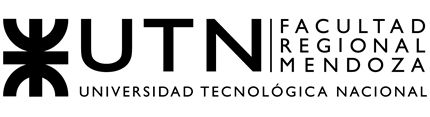
</div>
</center>
<center>
    <div style="font-family: 'Georgia', serif; font-size: 24px;">
        <p><strong>Análisis de Señales y Sistemas</strong></p>
        <p><strong>Departamento de Ingeniería en Tecnologías Electrónicas</strong></p>
    </div>
</center>

# Laboratorio n° 1: Señales y operaciones

**Asignatura:** Análisis de Señales y Sistemas
**Requisitos previos:** Módulos 1 a 9 y Laboratorio 0

---

## Introducción

Hasta acá usaste Python para calcular: resolver una fórmula, recorrer una lista, graficar una función. En este laboratorio empezás a usarlo con otro propósito: **construir señales y manipularlas**.

Una señal, en la computadora, no es una curva continua: es una **lista finita de valores** junto con la lista de los instantes en los que fueron tomados. Dos arrays de la misma longitud, uno con los tiempos y otro con los valores. Todo lo que hacemos con señales —retardarlas, reflejarlas, combinarlas, activarlas y desactivarlas— se traduce en operaciones con arrays de NumPy como las del Módulo 7, y se visualiza con los gráficos del Módulo 8. Lo nuevo, en su mayor parte, no es la herramienta: es la interpretación.

Aun así, este laboratorio necesita **algunos recursos que los módulos no alcanzan a cubrir**: la comparación de arrays para construir señales definidas por tramos, algunas funciones adicionales de NumPy y la forma de reproducir una señal como sonido. Todos se presentan acá, en celdas provistas que solo hay que ejecutar, y están señaladas como tales para que reconozcas cuándo aparece contenido nuevo.

Las operaciones que practicás acá son exactamente las que después vas a necesitar para entender la convolución, así que conviene dominarlas bien.

Al completar este laboratorio vas a poder:

- Construir señales elementales (escalón, pulso, rampa, exponencial, sinusoide) sobre un eje de tiempo dado.
- Desplazar una señal en el tiempo y explicar el signo del desplazamiento.
- Reflejar una señal respecto del origen.
- Escalar en amplitud, sumar y multiplicar señales, y distinguir qué efecto audible tiene cada operación.
- Recortar un tramo de una señal con *slicing* y con máscaras booleanas.

---

## Instrucciones generales

- Completá el código en las celdas marcadas con `# Tu código aquí`.
- Respondé las preguntas de análisis en las celdas de texto (tipo Markdown).
- Ejecutá las celdas en orden: varios ejercicios reutilizan variables definidas en ejercicios anteriores.
- Varios ejercicios generan sonido. Si estás en un entorno sin audio, el gráfico alcanza para resolverlos.

## IMPORTANTE: qué celdas podés modificar

Este laboratorio es un **entregable**. Solo debés completar las celdas de actividad, que son las que aparecen con el comentario `# Tu código aquí` o el texto `*(Escribí tu respuesta acá)*`. Todas las demás celdas (enunciados, explicaciones, ejemplos provistos y el encabezado) **no deben modificarse**: la corrección se hace celda por celda de manera automática y alterar lo que no corresponde puede invalidar tu entrega.

Si necesitás probar algo fuera de una celda de actividad, hacelo en una copia aparte y revertí los cambios antes de entregar.

---
## Preparación

Ejecutá la celda que sigue **una sola vez** al empezar. Además de importar las librerías, define dos elementos que se usan en todo el laboratorio:

- **`t`** es el **eje de tiempo**: un array de NumPy que contiene **tiempos medidos en segundos**, no valores de ninguna señal. Sus elementos son $-2$; $-1{,}995$; $-1{,}99$; … y así hasta $5$: son 1401 números, separados 5 ms uno del siguiente, o sea 200 por segundo. Cada uno indica un momento en el que se va a mirar la señal.

  Una señal queda representada, entonces, por **dos arrays de la misma longitud** que se leen en paralelo: `t` dice **cuándo** y el otro dice **cuánto vale la señal en ese momento**. Si `escalon` es una señal construida sobre `t`, su primer elemento `escalon[0]` es el valor en $t = -2$ s, el segundo `escalon[1]` es el valor en $t = -1{,}995$ s, y así hasta el último. Como se corresponden posición a posición, cuando más adelante recortes una señal vas a tener que recortar su eje con el mismo criterio.

  El eje comienza en $-2$ s, y no en 0, porque en el ejercicio 5 vas a reflejar señales y necesitás observar qué ocurre antes del origen.

- **`fs`** es la **frecuencia de muestreo**: la cantidad de **muestras por segundo** con la que se representa una señal que se va a escuchar. El valor 44100 es el estándar del audio digital. El eje `t` de arriba tiene apenas 200 valores por segundo: alcanza para dibujar, pero no para representar sonido, y por eso más adelante se define un segundo eje mucho más denso.

Si en algún momento una celda falla, lo más probable es que esta no se haya ejecutado.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Audio no pertenece a NumPy ni a Matplotlib: proviene de IPython, el sistema
# interactivo sobre el que funcionan Colab y Jupyter, y permite reproducir un
# array como sonido. Más abajo se explica cómo se usa.
from IPython.display import Audio

# Eje de tiempo: 1401 tiempos entre -2 s y 5 s, uno cada 5 ms. Contiene
# tiempos en segundos, no valores de señal (ver la explicación de arriba).
t = np.linspace(-2, 5, 1401)

# Frecuencia de muestreo, en muestras por segundo, para las señales audibles.
fs = 44100

print(f"Versión de NumPy: {np.__version__}")
print(f"Eje t: de {t[0]:.1f} s a {t[-1]:.1f} s, "
      f"{t.size} valores separados {1000 * (t[1] - t[0]):.0f} ms")

---
## Sección A: Construir señales elementales

Cada señal que construyas en esta sección es un array de NumPy de la misma longitud que `t`, que se lee en paralelo con él: el elemento de índice `i` es el valor que la señal toma en el instante `t[i]`. Más adelante vas a trabajar sobre un segundo eje de tiempo, mucho más denso, pero la relación entre los dos arrays es siempre la misma.

### Una técnica nueva: comparar el eje de tiempo

En el Módulo 7 aprendiste a crear arrays, a operarlos con aritmética vectorizada y a recortarlos con *slicing*. Para construir señales definidas **por tramos** —una que permanece en cero hasta cierto instante y a partir de ahí se activa— hace falta un recurso más, que **no aparece en los módulos** y se presenta acá.

La idea es comparar el eje de tiempo con un número. En el Módulo 2 viste que una comparación como `3 >= 0` devuelve un booleano, `True` o `False`. Cuando el que compara es un **array**, NumPy hace lo mismo que con la aritmética vectorizada: compara elemento por elemento y devuelve un **array de booleanos**, uno por cada instante.

Ese array de booleanos se convierte en números con el método `.astype(float)`, que transforma cada `True` en `1.0` y cada `False` en `0.0`. El resultado ya es una señal: vale 1 donde la condición se cumple y 0 donde no.

Hay dos detalles que conviene tener presentes:

- Para combinar dos condiciones se usan `&` ("y") y `|` ("o"), **no** los operadores `and` / `or` del Módulo 2, que esperan un único valor booleano y producen un error cuando reciben un array completo. Además hay que encerrar cada condición entre paréntesis, porque `&` tiene mayor prioridad que `>=`.
- El mismo array de booleanos, sin convertir a `float`, sirve para **recortar**: escrito entre corchetes, `x[mascara]` devuelve solamente los elementos donde la máscara vale `True`. A eso se le llama *máscara booleana*, y lo vas a usar en el ejercicio 8.

La celda que sigue muestra las tres operaciones sobre un eje reducido, de 9 instantes, para que puedas leer los arrays completos. Ejecutala y compará cada salida con la anterior. No hay nada que completar.

In [ ]:
# Eje de prueba, deliberadamente corto para poder ver los arrays completos.
t_demo = np.linspace(-2, 2, 9)
print("t_demo          =", t_demo)

# 1) Comparar un array con un número da un array de booleanos.
condicion = t_demo >= 0
print("t_demo >= 0     =", condicion)

# 2) .astype(float) convierte True en 1.0 y False en 0.0: ya es una señal.
print("como señal      =", condicion.astype(float))

# 3) Dos condiciones se combinan con & (cada una entre paréntesis).
print("0 <= t < 1      =", ((t_demo >= 0) & (t_demo < 1)).astype(float))

# 4) La misma máscara, sin convertir, sirve para recortar: devuelve un array
#    MÁS CORTO, solo con los elementos donde la máscara vale True.
print("t_demo[cond]    =", t_demo[condicion])

Esa es toda la técnica. Con ella se construyen el escalón, el pulso y cualquier señal que se active o se desactive en un instante determinado.

Observá la diferencia entre las salidas 3 y 4, porque sobre ella se pregunta al final del laboratorio: convertir a `float` **conserva la longitud** del array y anula las muestras que no cumplen la condición, mientras que usar la máscara entre corchetes **acorta** el array y las elimina.

### Ejercicio 1 — Escalón y pulso rectangular

**Objetivo:** Construir señales definidas por tramos a partir de comparaciones sobre el eje de tiempo.

Un **escalón** modela una magnitud que se activa en un instante y permanece activa: al cerrar una llave, la fuente queda conectada. Un **pulso rectangular** modela una magnitud que se activa y luego se desactiva: la ráfaga que emite un radar antes de quedar a la espera del eco.

**Enunciado:**

1. Construí `escalon`, que valga `0.0` para `t < 0` y `1.0` para `t >= 0`.
2. Construí `pulso`, que valga `1.0` solamente entre `t = 0` y `t = 1` segundo (incluyendo el 0, sin incluir el 1), y `0.0` en el resto.
3. Graficá las dos señales en dos paneles, uno arriba del otro, que compartan el eje horizontal.
4. Ponele a cada panel su título, etiquetas en los ejes y grilla.

> **Pista 1:** para combinar dos condiciones sobre arrays usá el operador `&`, con cada condición entre paréntesis, como en la celda anterior. El `and` de Python no funciona con arrays.
>
> **Pista 2:** los paneles se arman con `plt.subplots`, igual que en el Módulo 8. Para que además **compartan** el eje horizontal —que es lo que se pide acá— hay un argumento que el módulo no llega a mostrar: `plt.subplots(2, 1, figsize=(8, 5), sharex=True)`. Con eso los dos paneles quedan alineados y solo el de abajo lleva las marcas de tiempo, así que el `set_xlabel` va únicamente en ese.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Observá con detalle el gráfico del escalón en el entorno de `t = 0`. El salto no aparece como una línea perfectamente vertical, sino como un segmento inclinado. ¿Por qué ocurre esto, si la señal que definimos pasa de 0 a 1 de manera instantánea?

*(Escribí tu respuesta acá)*

### Una función para reutilizar

Ahora que construiste el pulso paso a paso en el ejercicio 1, ese mismo cálculo queda disponible en una función. La vas a necesitar en los ejercicios 4 y 9, y te evita repetir la misma línea de comparaciones cada vez.

Ejecutá la celda para que la función quede definida. No hay nada que completar acá.

In [ ]:
def pulso_en(t, inicio, ancho):
    """Pulso rectangular de amplitud 1.

    Parámetros
    ----------
    t : array
        Eje de tiempo.
    inicio : float
        Instante en el que empieza el pulso, en segundos.
    ancho : float
        Duración del pulso, en segundos.

    Devuelve
    --------
    array
        Vale 1.0 entre `inicio` e `inicio + ancho`, y 0.0 en el resto.
    """
    return ((t >= inicio) & (t < inicio + ancho)).astype(float)


print("Función pulso_en() lista para usar.")

### Ejercicio 2 — Exponencial decreciente: un capacitor que se descarga

**Objetivo:** Combinar una función continua con un escalón para que la señal exista recién a partir de un instante.

Cuando un capacitor cargado a 12 V se descarga sobre una resistencia, su tensión no cae de manera instantánea: decae siguiendo una exponencial

$$v(t) = V_0 \, e^{-t/\tau}$$

donde $\tau = RC$ es la **constante de tiempo** del circuito. Pero esa fórmula solo tiene validez a partir del instante en que se conecta la resistencia. Antes de ese instante la tensión era constante y la fórmula no se aplica: si la evaluaras para `t` negativo obtendrías valores crecientes, sin sentido físico.

La forma habitual de resolverlo es **multiplicar por el escalón**: donde el escalón vale 0, la señal se anula.

**Enunciado:**

1. Definí `V0 = 12.0` (volts) y `tau = 1.0` (segundos).
2. Construí `v` como la exponencial $V_0 e^{-t/\tau}$ multiplicada por el `escalon` del ejercicio 1, de modo que valga `0.0` para todo `t < 0`.
3. Graficá `v` en función de `t`, con título, etiquetas y grilla.
4. Imprimí cuánto vale la tensión en `t = tau` y qué porcentaje de `V0` representa.

> **Pista:** el eje `t` no contiene el instante exacto que buscás, sino el más cercano de los 1401 que lo componen. Para determinar su índice se usa `np.argmin(np.abs(t - instante))`: `t - instante` mide la distancia de cada instante del eje al instante buscado, `np.abs` la vuelve positiva, y `np.argmin` —una función que el Módulo 7 no presenta, a diferencia de `np.min`— devuelve el **índice** donde ocurre ese mínimo, en lugar del valor. Con ese índice ya podés leer la señal: `v[i]`.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

El valor que imprimiste en `t = tau` da siempre el mismo porcentaje de `V0`, sin importar cuánto valgan `V0` y `tau`. ¿Cuál es ese porcentaje y por qué no depende de los parámetros del circuito?

*(Escribí tu respuesta acá)*

### Un segundo eje de tiempo, para lo que se escucha

El eje `t` que venimos usando tiene 1401 instantes repartidos en 7 segundos, uno cada 5 ms: suficiente para dibujar un escalón o una exponencial, pero insuficiente para representar un sonido. Una nota musical de 440 Hz completa una oscilación cada 2,3 ms, de manera que sobre `t` no entraría ni un período entero entre dos instantes consecutivos. Hace falta una frecuencia de muestreo mucho mayor.

Por eso definimos **`t_audio`**: 2 segundos con `fs` instantes por segundo, es decir 88 200 en total, separados unos 23 µs. Es el eje que van a usar todos los ejercicios que produzcan sonido, de acá hasta el final.

Aparece ahí un argumento de `np.linspace` que el Módulo 7 no menciona: **`endpoint=False`**. Por defecto `linspace` incluye los dos extremos del intervalo, y para dibujar una curva eso es adecuado. Pero cuando la señal se va a **repetir** —como en el ejercicio 9— el último instante coincidiría con el primero de la repetición siguiente y quedaría una muestra duplicada, que se percibe como un chasquido. `endpoint=False` excluye el extremo derecho y evita ese problema.

Ejecutá la celda. No hay nada que completar.

In [ ]:
# endpoint=False evita duplicar el instante final, que es lo apropiado cuando
# la señal se va a reproducir o repetir.
t_audio = np.linspace(0, 2, int(2 * fs), endpoint=False)

print(f"Eje t_audio: {t_audio.size} instantes para {t_audio.size / fs:.2f} s")

### Cómo se escucha una señal

Hasta acá la única forma de examinar una señal fue graficarla. También es posible **reproducirla**: la celda de importaciones trajo `Audio`, una clase de IPython —el sistema interactivo sobre el que funcionan Colab y Jupyter, ajeno tanto a NumPy como a Matplotlib— que toma un array y muestra un reproductor de sonido.

Se usa así, con dos argumentos además de la señal:

```python
Audio(mi_senal, rate=fs, normalize=False)
```

`rate` es la frecuencia de muestreo, y le indica a qué velocidad reproducir las muestras. `normalize` merece una explicación aparte, porque de su valor depende que el resto del laboratorio tenga sentido.

Por defecto `Audio` **normaliza**: antes de reproducir, reescala la señal para que su valor máximo llegue al tope del rango disponible. Es cómodo cuando solo interesa oír una grabación, pero acá resulta contraproducente, porque significa que una sinusoide de amplitud `0.5` y una de amplitud `0.05` se escucharían **exactamente igual de fuerte**: la amplitud con la que construiste el array dejaría de tener efecto audible. Con `normalize=False` el reproductor toma los valores tal como están, y entonces la amplitud del array se corresponde con el volumen que oís.

Hay tres detalles más que conviene conocer antes de usarla, porque de lo contrario parecería que no funciona:

- **Tiene que ser la última línea de la celda.** Colab muestra automáticamente el resultado de la última expresión de cada celda, y así es como aparece el reproductor. Si después del `Audio(...)` colocás un `print` o un `plt.show()`, el reproductor no se muestra. Cuando una celda tenga gráfico y sonido, ubicá siempre el `Audio` al final.
- **Los valores tienen que quedar dentro del rango −1 a 1.** Es el rango que admite el audio digital, y con `normalize=False` la celda directamente falla si algún valor lo excede, con el mensaje `Audio data must be between -1 and 1 when normalize=False`. Por eso en los ejercicios las amplitudes son `0.5` o `0.6`, y cuando se suman varias señales el resultado se divide: si al sumar tres sinusoides de amplitud 1 no dividieras por 3, el resultado podría llegar a 3 y la celda no se ejecutaría.
- **El reproductor no se inicia automáticamente:** hay que presionar el botón de reproducción. Y si trabajás en un equipo sin audio, todos los ejercicios se pueden resolver igualmente a partir del gráfico.

La celda que sigue genera un tono breve de prueba para que confirmes que el audio funciona antes de continuar. Ejecutala y presioná el botón de reproducción. No hay nada que completar.

In [ ]:
# Medio segundo de un tono de 440 Hz, solo para probar el reproductor.
prueba = 0.3 * np.sin(2 * np.pi * 440 * t_audio[:int(0.5 * fs)])

print("Si abajo aparece un reproductor, presionalo: debería oírse un tono breve.")

# Última línea de la celda, deliberadamente: es lo que hace visible el reproductor.
Audio(prueba, rate=fs, normalize=False)

### Ejercicio 3 — Una sinusoide que se puede escuchar

**Objetivo:** Construir una sinusoide de frecuencia dada y relacionar su expresión matemática con lo que se ve y se oye.

Un diapasón de orquesta vibra a **440 Hz**: es la nota La que se usa para afinar. Una sinusoide pura de esa frecuencia se escribe

$$x(t) = A \sin(2\pi f t)$$

**Enunciado:**

1. Construí `la440`, una sinusoide de amplitud `0.5` y frecuencia `440` Hz sobre el eje `t_audio`.
2. Graficá **solo los primeros 3 períodos** de la señal, con el eje horizontal en milisegundos. Poné título, etiquetas y grilla.
3. Reproducí la señal con `Audio(la440, rate=fs, normalize=False)`, **como última línea de la celda**, después del gráfico y de cualquier `print`.

> **Pista:** un período dura `1/440` segundos. Para determinar cuántas muestras ocupan 3 períodos, considerá cuántas muestras hay en un segundo (`fs`) y planteá una regla de tres. Convertí el resultado a entero con `int()` antes de usarlo para hacer *slicing*.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Si cambiaras la amplitud de `0.5` a `0.25` y volvieras a reproducir la señal, ¿qué diferencia notarías al escucharla? ¿Y si en cambio dejaras la amplitud en `0.5` pero cambiaras la frecuencia de `440` a `880` Hz?

*(Escribí tu respuesta acá)*

---
## Sección B: Transformaciones del eje temporal

Las operaciones de la sección anterior modificaban los **valores** de la señal. Las de esta sección modifican el **eje de tiempo**: la señal es la misma, pero ocurre en otro momento o en otro sentido.

Son dos operaciones y conviene tenerlas muy claras, porque la convolución —que vas a ver en el próximo laboratorio— consiste justamente en desplazar y reflejar una señal respecto de otra.

### Ejercicio 4 — Desplazamiento temporal: el eco de un pulso

**Objetivo:** Desplazar una señal en el tiempo y entender qué sentido tiene el signo del desplazamiento.

Un sonar emite una ráfaga corta y luego queda a la escucha. Si hay un obstáculo, un tiempo después regresa la misma ráfaga, atenuada: es el eco. Lo que recibe el sonar es la suma de ambas, la directa y la retardada.

Desplazar una señal en el tiempo se escribe $x(t - t_0)$: la señal desplazada toma en el instante $t$ el valor que la original tenía en $t - t_0$.

**Enunciado:**

1. Construí `directo`, un pulso de ancho `0.3` s que empieza en `t = 0`, usando la función `pulso_en()`.
2. Construí `eco`, el mismo pulso pero empezando en `t = 1.5` s y con amplitud `0.4`.
3. Construí `recibido` como la suma de los dos.
4. Graficá las tres señales en tres paneles apilados que compartan el eje horizontal, con títulos, etiquetas y grilla. Es el mismo armado del ejercicio 1, con `sharex=True`, pero con tres filas en lugar de dos.

> **Pista:** en `pulso_en(t, inicio, ancho)`, el desplazamiento se logra modificando el argumento `inicio`. Para escalar la amplitud, multiplicá el pulso por el factor deseado.
>
> Vale la pena ver por qué eso equivale a la fórmula: `pulso_en(t, 1.5, 0.3)` compara `t >= 1.5`, que es exactamente la misma condición que `t - 1.5 >= 0`. Correr el inicio del pulso 1,5 s hacia adelante y evaluar la señal original en $t - 1{,}5$ son la misma operación escrita de dos maneras.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Para retardar la señal escribimos $x(t - t_0)$ con $t_0$ **positivo**, es decir, con un signo **menos** dentro del argumento. A primera vista resulta contradictorio: uno esperaría que restar desplazara la señal hacia la izquierda. Explicá por qué restar dentro del argumento retarda la señal en lugar de adelantarla.

*(Escribí tu respuesta acá)*

### Una señal asimétrica para poder ver la reflexión

Para que el próximo ejercicio tenga sentido hace falta una señal que **no** sea simétrica respecto del origen: si usáramos un pulso centrado en 0, al reflejarlo quedaría idéntico y el efecto no sería visible.

Se provee entonces una rampa que crece de 0 a 1 entre `t = 0` y `t = 1`, y se mantiene en 1 a partir de ahí. Está definida como una **función del eje de tiempo**, y eso es deliberado: es lo que te va a permitir reflejarla simplemente evaluándola en `-t`.

Ejecutá la celda. No hay nada que completar.

In [ ]:
def rampa_saturada(t):
    """Rampa que sube de 0 a 1 entre t=0 y t=1, y se mantiene en 1 después.

    `np.clip(t, 0, 1)` recorta el eje: los valores por debajo de 0 pasan a 0,
    los que están por encima de 1 pasan a 1, y los intermedios quedan sin
    cambio. Es una forma compacta de definir una señal por tramos.
    """
    return np.clip(t, 0, 1)


print("Función rampa_saturada() lista para usar.")

### Ejercicio 5 — Reflexión: la señal vista al revés

**Objetivo:** Reflejar una señal respecto del origen de tiempo. Es la operación que después hace falta para entender la convolución.

Reflejar una señal es evaluarla en $-t$: lo que ocurría en el futuro pasa a ocurrir en el pasado y viceversa. Es la señal recorrida en sentido inverso.

**Enunciado:**

1. Construí `x` evaluando `rampa_saturada()` en el eje `t`.
2. Construí `x_reflejada` evaluando la **misma función** en `-t`.
3. Graficá las dos en un mismo gráfico, cada una con su `label`, y agregá la leyenda.
4. Marcá el origen con una línea vertical usando `plt.axvline(0, color="gray", linestyle="--")`.

> **Pista:** no hace falta invertir el array con *slicing*. Como `rampa_saturada` recibe el eje de tiempo como argumento, alcanza con pasarle `-t` en lugar de `t`.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Existen señales que quedan **exactamente iguales** después de reflejarlas, es decir que cumplen $x(-t) = x(t)$. Proponé un ejemplo concreto de una señal así y explicá qué particularidad tiene su forma. ¿Alguna de las que construiste en este laboratorio cumple esa condición?

*(Escribí tu respuesta acá)*

---
## Sección C: Combinar señales entre sí

Hasta acá trabajamos con una señal por vez. Ahora vamos a combinar dos o más, y hay dos formas de hacerlo que producen resultados completamente distintos:

- **Sumarlas** las superpone: ambas coexisten, sonando de manera simultánea, y cada una conserva su identidad.
- **Multiplicarlas** punto a punto hace que una controle a la otra: una pasa a ser la *envolvente* que le da forma a la otra.

Los dos ejercicios que siguen exploran cada una de estas operaciones.

### Ejercicio 6 — Sumar señales: acordes y batidos

**Objetivo:** Escalar en amplitud y sumar señales, y comprobar que el resultado depende de cuán separadas estén las frecuencias.

**Parte A.** Cuando tres notas suenan simultáneamente, la señal resultante es la suma de las tres. Vas a construir un acorde de Do mayor con las frecuencias Do = 261,63 Hz, Mi = 329,63 Hz y Sol = 392,00 Hz.

1. Construí las tres sinusoides de amplitud `1.0` sobre `t_audio`.
2. Sumalas y dividí el resultado por `3`, para que la amplitud final no supere 1.
3. Guardá el resultado en `acorde`, graficá los primeros 20 ms y reproducilo.

**Parte B.** Ahora vas a sumar dos frecuencias **muy cercanas**: 440 Hz y 443 Hz, con amplitud `0.5` cada una. Es lo que se escucha al afinar una guitarra cuando dos cuerdas todavía no coinciden.

1. Construí las dos sinusoides y sumalas en `batido`.
2. Graficá la señal **completa** (los 2 segundos) y reproducila.
3. Observá la forma de la envolvente.

> **Pista:** para graficar los primeros 20 ms, calculá a cuántas muestras equivalen con `int(0.020 * fs)` y usá *slicing*.

In [ ]:
# Tu código aquí

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

En la parte B el volumen crece y decrece de manera periódica, con una pulsación regular, aunque las dos sinusoides que sumaste tienen amplitud constante. Contá cuántos **máximos de amplitud** aparecen por segundo en el gráfico y relacioná ese número con las frecuencias `f1` y `f2`. ¿Por qué en la parte A, con tres notas, no se percibe ese efecto?

*(Escribí tu respuesta acá)*

### Ejercicio 7 — Multiplicar señales: una nota que se apaga

**Objetivo:** Usar el producto punto a punto para que una señal le dé forma a otra.

Cuando punteás una cuerda de guitarra, el tono no suena con volumen constante: comienza con amplitud máxima y decae progresivamente. La señal es el producto de dos factores: el **tono** (la sinusoide, que determina la altura) y la **envolvente** (una exponencial decreciente, que determina cómo se extingue).

**Enunciado:**

1. Construí `envolvente` como $e^{-t/\tau_n}$ sobre `t_audio`, con `tau_n = 0.4` segundos.
2. Construí `tono`, una sinusoide de amplitud `0.6` y frecuencia `330` Hz (un Mi) sobre `t_audio`.
3. Multiplicalos punto a punto y guardá el resultado en `nota`.
4. Graficá `nota` completa y superponé la `envolvente` (y su versión negativa, `-envolvente`) con línea punteada, para observar cómo la encierra.
5. Reproducí `nota`.

> **Pista:** para dibujar la envolvente sobre el mismo gráfico usá dos llamadas más a `plt.plot`, como cuando superponías señales en el Módulo 8. Para distinguirlas de la señal, pasales `linestyle="--"`: es la forma explícita del atajo `"r--"` que presenta ese módulo, y se combina con `color=` como cualquier otro argumento. Multiplicá la envolvente por la amplitud del tono para que coincida con los picos de la señal.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

En el ejercicio 6 sumaste dos sinusoides y en este multiplicaste una sinusoide por una exponencial. Explicá, en términos de lo que se escucha, cuál es la diferencia entre **sumar** dos señales y **multiplicarlas** punto a punto.

*(Escribí tu respuesta acá)*

---
## Sección D: Recortar un tramo

### Ejercicio 8 — Extraer un tramo: *slicing* y máscaras booleanas

**Objetivo:** Extraer un tramo temporal de una señal por dos caminos distintos, y comprender en qué se diferencian.

Con frecuencia interesa analizar solo un tramo de una señal: el primer medio segundo de una grabación, o el intervalo comprendido entre dos instantes. Hay dos formas de hacerlo con NumPy y conviene conocer ambas: el *slicing* del Módulo 7, que trabaja con **índices** del array, y la máscara booleana presentada al comienzo, que trabaja con **valores de tiempo**.

**Enunciado:**

1. Usando *slicing*, extraé el **primer medio segundo** de la señal `nota` del ejercicio anterior. Guardalo en `tramo_slice` y guardá el tramo correspondiente del eje en `t_slice`.
2. Usando una **máscara booleana**, extraé el tramo de `nota` comprendido entre `0.5` s y `1.0` s. Guardalo en `tramo_mascara` y el eje correspondiente en `t_mascara`.
3. Imprimí cuántas muestras tiene cada tramo y cuántos segundos representan.
4. Graficá los dos tramos en dos paneles apilados, esta vez **sin** `sharex`, porque cubren intervalos de tiempo distintos y cada uno necesita su propia escala. Recordá entonces asignarle `set_xlabel` a ambos.

> **Pista:** la máscara se construye igual que el pulso del ejercicio 1, con `&` entre dos condiciones, pero en lugar de convertirla a `float` la usás directamente como índice: `nota[mascara]` devuelve solo los elementos donde la máscara vale `True`.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Recortar un tramo con una máscara booleana y **multiplicar** la señal por un pulso rectangular (como hiciste en el ejercicio 1) parecen operaciones equivalentes: en ambos casos se conserva una parte de la señal. Sin embargo, el resultado no es el mismo. ¿En qué se diferencian?

*(Escribí tu respuesta acá)*

---
## Sección E: Mini-proyecto

### Ejercicio 9 — Sintetizar el "beep-beep" de una alarma

**Objetivo:** Integrar todo lo del laboratorio para construir una señal con estructura, usando únicamente las operaciones practicadas.

Una alarma de retroceso emite un *beep-beep*: dos ráfagas cortas de un tono agudo, separadas por un silencio, y el patrón se repite. Vas a sintetizarla desde cero.

**Enunciado:**

1. Construí un eje `t_beep` de **1 segundo** con `fs` muestras por segundo (usá `endpoint=False`).
2. Construí `tono_alarma`, una sinusoide de amplitud `0.5` y frecuencia `880` Hz sobre ese eje.
3. Construí `ventana` sumando **dos pulsos** con `pulso_en()`: uno de `0.15` s que comienza en `0.0` s, y otro de `0.15` s que comienza en `0.25` s.
4. Multiplicá el tono por la ventana y guardá el resultado en `un_ciclo`.
5. Repetí el patrón **3 veces** seguidas con `np.tile(un_ciclo, 3)` y guardalo en `alarma`.
6. Graficá `alarma` completa, con título, etiquetas y grilla.
7. Reproducila.

> **Pista:** el orden de las líneas importa poco, pero el razonamiento sí: primero construís un tono continuo, después una ventana que vale 1 donde el tono debe oírse y 0 donde no, y recién entonces los multiplicás. `np.tile(array, n)` —otra función que no aparece en el Módulo 7— concatena el array `n` veces consecutivas y devuelve uno `n` veces más largo. Para graficar el resultado vas a necesitar un eje de 3 segundos, que podés construir con `np.linspace` y `endpoint=False`.

In [ ]:
# Tu código aquí

**Pregunta de análisis:**

Para construir la alarma no generaste el silencio por separado ni concatenaste fragmentos: construiste un tono continuo y lo multiplicaste por una ventana. Explicá por qué esa estrategia funciona y qué ventajas tiene sobre la alternativa de concatenar tramos de tono y tramos de silencio.

*(Escribí tu respuesta acá)*

---
## Antes de entregar

Verificá los siguientes puntos:

- [ ] Reinicié el entorno y ejecuté **todas** las celdas de arriba a abajo sin errores (**Entorno de ejecución > Reiniciar y ejecutar todo**).
- [ ] Los valores numéricos que imprimo son razonables (no hay infinitos, ni `NaN`, ni inconsistencias de unidades).
- [ ] Todos los gráficos tienen título, etiquetas en los ejes y grilla.
- [ ] Respondí **todas** las preguntas de análisis con mis propias palabras.
- [ ] No modifiqué ninguna celda fuera de las de actividad.

---
## Cierre

Terminaste el Laboratorio 1. Ahora contás con un repertorio completo de operaciones sobre señales: construirlas por tramos, desplazarlas, reflejarlas, escalarlas, sumarlas, multiplicarlas y recortarlas.

Dos de esas operaciones conviene que queden especialmente claras: el **desplazamiento** del ejercicio 4 y la **reflexión** del ejercicio 5. En el Laboratorio 2 vas a ver la convolución, que consiste justamente en reflejar una señal, desplazarla y medir cuánto se superpone con otra en cada posición. Todo lo que necesitás para comprenderla ya lo practicaste acá.